In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Solution 1(a)

In [2]:
x = np.array([1, 2, 3, 4], dtype=float)
y = np.array([2, 4, 5, 8], dtype=float)

m = len(x)

A = np.array([
    [np.sum(x**2), np.sum(x)],
    [np.sum(x),    m]
])

rhs = np.array([
    np.sum(x*y),
    np.sum(y)
])

a, b = np.linalg.solve(A, rhs)

print("a =", a)
print("b =", b)

a = 1.9
b = 0.0


## Solution 1(b)

In [ ]:
def fitting_line(x, y):

    m = len(x)

    A = np.array([
        [np.sum(x**2), np.sum(x)],
        [np.sum(x),    m]
    ])

    rhs = np.array([
        np.sum(x*y),
        np.sum(y)
    ])

    a, b = np.linalg.solve(A, rhs)

    return a, b

# Solution 1(c)

In [4]:
np.random.seed(1)

m = 100

x = np.sort(np.random.random(m))
y = np.sort(np.random.random(m))

a, b = fitting_line(x, y)

print("a =", a)
print("b =", b)

a = 1.067071801117108
b = -0.03362758541078576


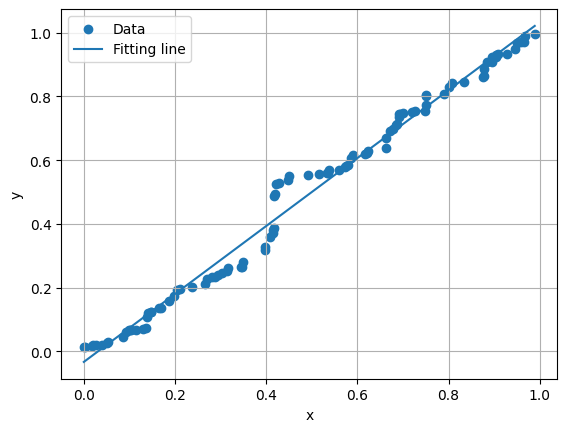

In [5]:
y_fit = a*x + b

plt.scatter(x, y, label="Data")
plt.plot(x, y_fit, label="Fitting line")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

## Solution 1(d)

In [6]:
def fitting_line_through_point(x, y, s, z):

    denominator = np.sum((x - s)**2)

    if denominator == 0:
        print("No unique solution.")
        return None, None

    a = np.sum((x - s)*(y - z)) / denominator
    b = z - a*s

    return a, b

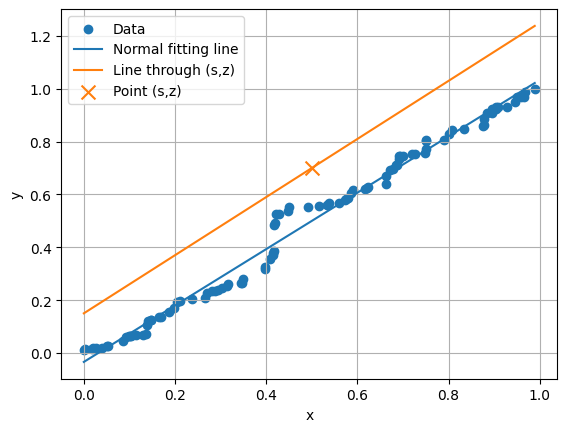

In [7]:
s = 0.5
z = 0.7

a2, b2 = fitting_line_through_point(x, y, s, z)

y_normal = a*x + b
y_constrained = a2*x + b2

plt.scatter(x, y, label="Data")
plt.plot(x, y_normal, label="Normal fitting line")
plt.plot(x, y_constrained, label="Line through (s,z)")
plt.scatter(s, z, marker="x", s=100, label="Point (s,z)")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

## Solution 2(a)

In [8]:
data = pd.read_csv("C:/Users/Shakeel M. Shajahan/Desktop/to_github/Non Linear optimisation/Exercise 2/winedata.csv")

print(data.head())
print()
print("Shape =", data.shape)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0           9.37             0.739        0.255            0.97      0.078   
1           8.34             0.433        0.160            1.77      0.121   
2           7.06             0.440        0.770            2.25      0.066   
3           9.82             0.758        0.303            1.79      0.038   
4           9.42             0.610        0.219            2.37      0.065   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                   44                    88  0.99626  3.11       0.58   
1                   34                    41  0.99823  3.17       0.96   
2                   18                    26  0.99589  3.54       0.98   
3                   39                    48  0.99591  3.34       0.52   
4                   30                    40  0.99599  3.37       0.59   

   alcohol  quality  
0     8.40        4  
1    10.30        5  
2    11.35        7 

In [9]:
X = data.iloc[:, 0:11].values
Y = data.iloc[:, 11].values

print("X shape =", X.shape)
print("Y shape =", Y.shape)

X shape = (1507, 11)
Y shape = (1507,)


In [10]:
# Split into training data and test data (80% training and 20% testing)

split = int(0.8 * len(X))

X_train = X[:split]
Y_train = Y[:split]

X_test = X[split:]
Y_test = Y[split:]

print("Training samples =", len(X_train))
print("Test samples =", len(X_test))

Training samples = 1205
Test samples = 302


## Solution 2(b)

In [12]:
ones = np.ones((len(X_train), 1))
A = np.hstack((X_train, ones))

left = A.T @ A
right = A.T @ Y_train

parameters = np.linalg.solve(left, right)

a = parameters[:11]
b = parameters[11]

print("a =", a)
print("b =", b)

a = [ 9.18696220e-05 -1.32095016e+00  3.23189908e-01  3.90837955e-03
 -2.08080834e+00 -1.56899912e-03  6.52950276e-04  1.00564515e+01
  6.92299570e-02  5.36742695e-01  3.80744192e-01]
b = -8.474726243046346


In [16]:
# Prediction with our regression parameters

Y_train_prediction = X_train @ a + b

print("First 10 predictions:")
print(Y_train_prediction[:10])

First 10 predictions:
[4.20598514 5.42939269 6.16140374 4.65220059 4.40855605 5.06202646
 5.15473195 5.87886545 5.23545901 5.59224   ]


## Solution 2(c)

In [17]:
# Validate with sklearn LinearRegression

model = LinearRegression()

model.fit(X_train, Y_train)

print("Our coefficients:")
print(a)

print()
print("Sklearn coefficients:")
print(model.coef_)

print()
print("Our b =", b)
print("Sklearn b =", model.intercept_)

Our coefficients:
[ 9.18696220e-05 -1.32095016e+00  3.23189908e-01  3.90837955e-03
 -2.08080834e+00 -1.56899912e-03  6.52950276e-04  1.00564515e+01
  6.92299570e-02  5.36742695e-01  3.80744192e-01]

Sklearn coefficients:
[ 9.18696219e-05 -1.32095016e+00  3.23189908e-01  3.90837955e-03
 -2.08080834e+00 -1.56899912e-03  6.52950276e-04  1.00564515e+01
  6.92299570e-02  5.36742695e-01  3.80744192e-01]

Our b = -8.474726243046346
Sklearn b = -8.474726240125378


## Solution 2(d)

In [18]:
# Test our parameters using the test set

Y_prediction = X_test @ a + b

mse = mean_squared_error(Y_test, Y_prediction)
r2 = r2_score(Y_test, Y_prediction)

print("Mean Squared Error =", mse)
print("R² score =", r2)

Mean Squared Error = 0.4661111318307228
R² score = 0.3115372211652322


In [19]:
# Compare some real and predicted values

for i in range(10):
    print(
        "Real =", Y_test[i],
        "   Predicted =", round(Y_prediction[i], 2)
    )

Real = 5    Predicted = 4.94
Real = 5    Predicted = 5.17
Real = 6    Predicted = 4.82
Real = 5    Predicted = 5.51
Real = 5    Predicted = 5.13
Real = 6    Predicted = 5.29
Real = 5    Predicted = 5.16
Real = 6    Predicted = 6.02
Real = 5    Predicted = 5.11
Real = 6    Predicted = 5.42


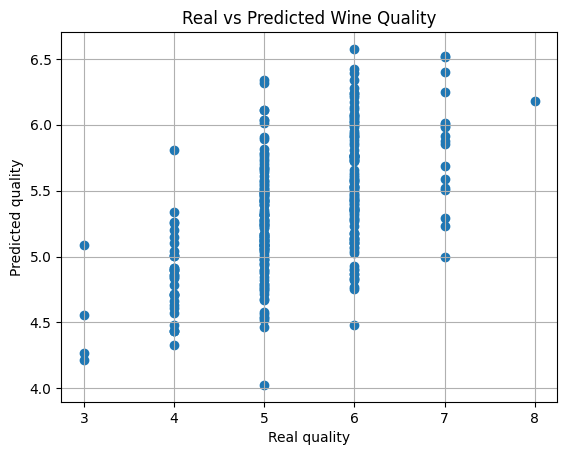

In [20]:
# Plot real quality against predicted quality

plt.scatter(Y_test, Y_prediction)

plt.xlabel("Real quality")
plt.ylabel("Predicted quality")
plt.title("Real vs Predicted Wine Quality")

plt.grid()
plt.show()